In [1]:
import os
import pickle
import numpy as np
np.random.seed(42)
import pandas as pd
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [2]:
dataset = "LastFM"
sim_metric = "cos"
topk = 100

### Get the topk similar user

In [3]:
# load the llm user embedding
user_emb = pickle.load(open(os.path.join(dataset+"/handled/", "usr_emb_np.pkl"), "rb"))

In [4]:
user_emb = np.asarray(user_emb, dtype=np.float32)
if sim_metric in ["cos", "sin"]:
    user_emb = user_emb / (np.linalg.norm(user_emb, axis=1, keepdims=True) + 1e-12)

N, d = user_emb.shape
topk = int(topk)

try:
    import faiss
    nlist = int(min(65536, max(1024, np.sqrt(N))))
    quantizer = faiss.IndexFlatIP(d)
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)
    train_n = int(min(200000, N))
    train_x = user_emb[np.random.choice(N, train_n, replace=False)] if train_n < N else user_emb
    index.train(train_x)
    index.add(user_emb)
    index.nprobe = int(min(64, max(8, nlist // 64)))

    k_search = topk + 1
    final_rank_matrix = np.empty((N, topk), dtype=np.int32)
    batch = 20000
    for start in range(0, N, batch):
        end = min(N, start + batch)
        _, I = index.search(user_emb[start:end], k_search)
        final_rank_matrix[start:end] = I[:, 1:topk+1]
except Exception as e:
    raise RuntimeError(
        "electronics 用户规模过大，不能构造 N×N 相似度矩阵。\n"
        "请安装 faiss 并使用该单元格的 ANN 检索，或改用分组/聚类候选集方案。\n"
        f"原始异常: {type(e).__name__}: {e}"
    )

WARNING clustering 1390 points to 1024 centroids: please provide at least 39936 training points


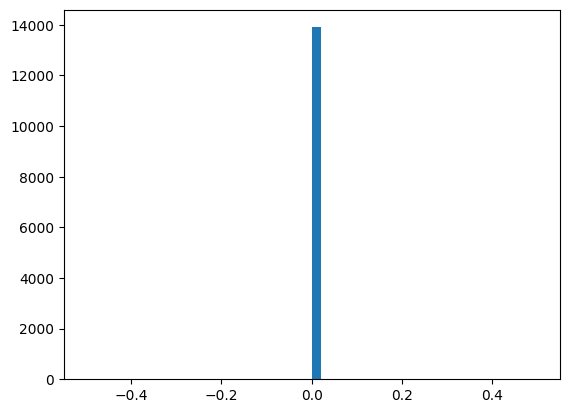

In [5]:
sample_n = int(min(2000, user_emb.shape[0]))
sample_idx = np.random.choice(user_emb.shape[0], sample_n, replace=False)
sample_nei = final_rank_matrix[sample_idx, :10]
sims = (user_emb[sample_idx][:, None, :] * user_emb[sample_nei]).sum(axis=-1).reshape(-1)
plt.hist(sims, bins=50)
plt.show()

In [6]:
rank_matrix = None

In [7]:
final_rank_matrix = final_rank_matrix[:, :topk]

### Get the sequence length of each user

In [8]:
User = defaultdict(list)
seq_len = []
usernum, itemnum = 0, 0
f = open('./%s/handled/%s.txt' % (dataset, "inter"), 'r')
for line in f:  # use a dict to save all seqeuces of each user
    u, i = line.rstrip().split(' ')
    u = int(u)
    i = int(i)
    usernum = max(u, usernum)
    itemnum = max(i, itemnum)
    User[u].append(i)

for user, seq in User.items():
    seq_len.append(len(seq))

In [9]:
sim_user_len = []
for sim_user_list in final_rank_matrix:
    avg_len = 0
    for sim_user in sim_user_list:
        avg_len += seq_len[sim_user] / topk
    sim_user_len.append(avg_len)

In [10]:
np.mean(sim_user_len), np.mean(seq_len)

(46.78999999999998, 44.46546762589928)

### Select the similar user

In [11]:
sim_users = []
for sim_user_list in final_rank_matrix:
    sim_users.append(np.random.choice(sim_user_list, 1)[0])

In [12]:
final_rank_matrix.shape

(1390, 100)

In [13]:
## Save llm embedding based similar users
pickle.dump(final_rank_matrix, open(os.path.join(dataset+"/handled/", "sim_user_100.pkl"), "wb"))